In [2]:
import tensorflow as tf
import kagglehub
import os

path = kagglehub.dataset_download("apollo2506/eurosat-dataset")

print(path)

Using Colab cache for faster access to the 'eurosat-dataset' dataset.
/kaggle/input/eurosat-dataset


In [3]:
base_path = "/kaggle/input/eurosat-dataset"

print(os.listdir(base_path))

['EuroSATallBands', 'EuroSAT']


In [4]:
eurosat_path = os.path.join(base_path, "EuroSAT")

print(eurosat_path)
print(os.listdir(eurosat_path))

/kaggle/input/eurosat-dataset/EuroSAT
['SeaLake', 'Highway', 'River', 'Pasture', 'Industrial', 'Residential', 'PermanentCrop', 'validation.csv', 'AnnualCrop', 'train.csv', 'test.csv', 'label_map.json', 'Forest', 'HerbaceousVegetation']


In [5]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

dataset = tf.keras.utils.image_dataset_from_directory(
    eurosat_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

class_names = dataset.class_names

print(class_names)

Found 27000 files belonging to 10 classes.
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


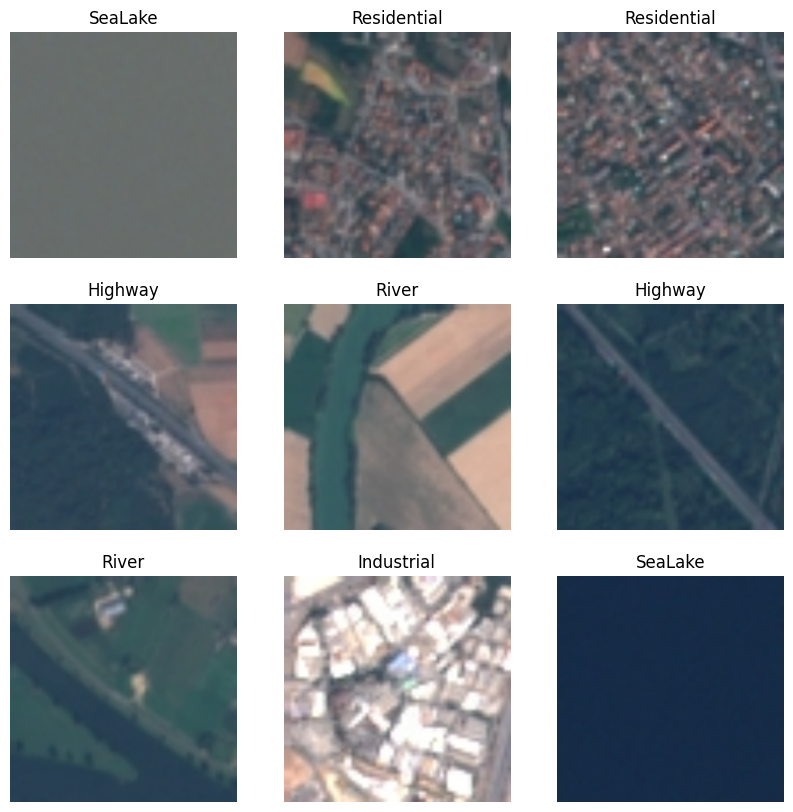

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
for images,labels in dataset.take(1):
  for i in range(9):
     plt.subplot(3, 3, i + 1)
     plt.imshow(images[i].numpy().astype("uint8"))
     plt.title(class_names[labels[i]])
     plt.axis("off")

plt.show()



In [7]:
base_model = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [8]:
from tensorflow.keras import layers, models

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [9]:
history = model.fit(
    dataset,
    epochs=10
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 91s 89ms/step - accuracy: 0.9183 - loss: 0.2442
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 73s 87ms/step - accuracy: 0.9524 - loss: 0.1445
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 73s 86ms/step - accuracy: 0.9590 - loss: 0.1202
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 73s 86ms/step - accuracy: 0.9665 - loss: 0.0989
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 73s 86ms/step - accuracy: 0.9669 - loss: 0.0925
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 73s 86ms/step - accuracy: 0.9730 - loss: 0.0769
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 73s 86ms/step - accuracy: 0.9760 - loss: 0.0693
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 73s 87ms/step - accuracy: 0.9770 - loss: 0.0676
Epoch 9/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 73s 86ms/step - accuracy: 0.9793 - loss: 0.0592
Epoch 10/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 87ms/step - accuracy: 0.9793 - loss: 0.0589


In [10]:
loss, accuracy = model.evaluate(dataset)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

844/844 ━━━━━━━━━━━━━━━━━━━━ 79s 88ms/step - accuracy: 0.9909 - loss: 0.0276
Test Loss: 0.02755996398627758
Test Accuracy: 0.990851879119873


In [11]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

full_dataset = tf.keras.utils.image_dataset_from_directory(
    eurosat_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=123
)

class_names = full_dataset.class_names

Found 27000 files belonging to 10 classes.


In [27]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    eurosat_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    eurosat_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

class_names = train_ds.class_names
num_classes = len(class_names)

Found 27000 files belonging to 10 classes.
Using 21600 files for training.
Found 27000 files belonging to 10 classes.
Using 5400 files for validation.


In [28]:
from tensorflow.keras.applications.resnet50 import preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))

In [29]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

In [30]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 99s 130ms/step - accuracy: 0.9206 - loss: 0.2395 - val_accuracy: 0.9522 - val_loss: 0.1462
Epoch 2/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 81s 120ms/step - accuracy: 0.9531 - loss: 0.1366 - val_accuracy: 0.9520 - val_loss: 0.1570
Epoch 3/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 80s 119ms/step - accuracy: 0.9622 - loss: 0.1072 - val_accuracy: 0.9535 - val_loss: 0.1565
Epoch 4/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 85s 126ms/step - accuracy: 0.9698 - loss: 0.0856 - val_accuracy: 0.9574 - val_loss: 0.1476
Epoch 5/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 80s 119ms/step - accuracy: 0.9711 - loss: 0.0809 - val_accuracy: 0.9598 - val_loss: 0.1504
Epoch 6/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 80s 119ms/step - accuracy: 0.9755 - loss: 0.0688 - val_accuracy: 0.9591 - val_loss: 0.1546
Epoch 7/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 82s 119ms/step - accuracy: 0.9797 - loss: 0.0564 - val_accuracy: 0.9622 - val_loss: 0.1540
Epoch 8/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 81s 120ms/step - accuracy: 0.9816 - loss: 0

In [38]:
from PIL import Image

img_path = list(dataset.file_paths)[0]
img = Image.open(img_path)
img.show()

In [33]:
print(class_names)

['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


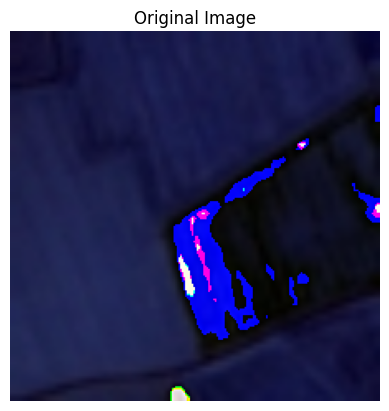

True Class: AnnualCrop
Predicted Class: AnnualCrop


In [36]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.applications.resnet50 import preprocess_input

for images, labels in train_ds.take(1):
    sample_image = images[0].numpy()
    true_label = labels[0].numpy()

plt.imshow(sample_image.astype("uint8"))
plt.title("Original Image")
plt.axis("off")
plt.show()

img = np.expand_dims(sample_image, axis=0)
img = preprocess_input(img)

prediction = model.predict(img, verbose=0)

predicted_class = class_names[np.argmax(prediction)]
true_class = class_names[true_label]

print("True Class:", true_class)
print("Predicted Class:", predicted_class)

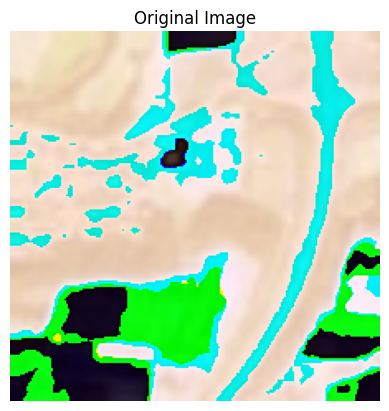

True Class: Highway
Predicted Class: Highway


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.applications.resnet50 import preprocess_input

for images, labels in train_ds.take(1):
    sample_image = images[0].numpy()
    true_label = labels[0].numpy()

plt.imshow(sample_image.astype("uint8"))
plt.title("Original Image")
plt.axis("off")
plt.show()

img = np.expand_dims(sample_image, axis=0)
img = preprocess_input(img)

prediction = model.predict(img, verbose=0)

predicted_class = class_names[np.argmax(prediction)]
true_class = class_names[true_label]

print("True Class:", true_class)
print("Predicted Class:", predicted_class)

In [39]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

In [40]:
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_true, y_pred)

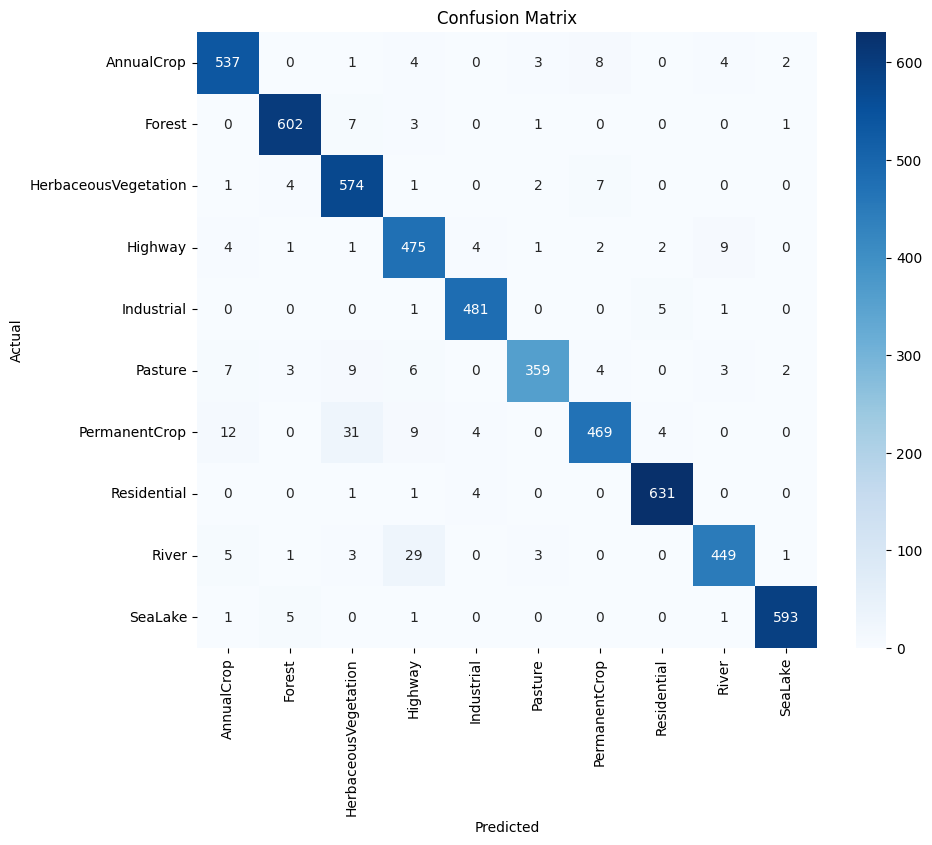

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()